# Task 1.1 — Sentiment Analysis with a Feedforward ANN

We classify Amazon product reviews as **positive (1)** or **negative (0)** using a
TF-IDF bag-of-words representation fed into a simple feedforward neural network.

**Pipeline overview**
```
Raw text  →  Preprocessing  →  TF-IDF vectors  →  ANN  →  {0, 1}
```

## Setup & Imports

In [1]:
import warnings
import pathlib
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

from utils import device_check, fit, evaluate
from plotting_tools import plot_confusion_matrix

# Suppress NumPy 2.4 VisibleDeprecationWarning triggered inside torchvision
warnings.filterwarnings("ignore", category=np.exceptions.VisibleDeprecationWarning)
# Suppress tqdm ipywidgets warning (harmless fallback to terminal progress bar)
warnings.filterwarnings("ignore", message="IProgress not found")

device = device_check()

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.11.0+cu130 | Python: 3.11.15 | OS: Linux 5.15.0-168-generic
CUDA available: True
GPUs: 1 x NVIDIA GeForce RTX 2080 Ti (11.3 GB)
CUDA: 13.0 | cuDNN: 91900
Using cuda / NVIDIA GeForce RTX 2080 Ti


In [2]:
LOG_WANDB   = False  # Set False to disable wandb logging
NUM_WORKERS = 8
PIN_MEMORY  = True
SEED = 1

# Make results reproducible
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## ANN Architecture

A feedforward network with **BatchNorm** and **Dropout** for regularization, with adjustable hidden layer count/size.

In [3]:
class SentimentANN(nn.Module):
    def __init__(self, input_dim: int, hidden_dims: list[int],
                 num_classes: int = 2,
                 activation: nn.Module = nn.ReLU(), dropout: float = 0.3):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(prev_dim, h),
                nn.BatchNorm1d(h),
                activation,
                nn.Dropout(dropout),
            ]
            prev_dim = h
        layers.append(nn.Linear(prev_dim, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

---
## Initial Test — 1 K Amazon Reviews

### Load Pre-split Data

In [4]:
SPLITS_DIR = pathlib.Path('../data/splits')

train_df = pd.read_csv(SPLITS_DIR / '1k_train.csv')
val_df   = pd.read_csv(SPLITS_DIR / '1k_val.csv')
test_df  = pd.read_csv(SPLITS_DIR / '1k_test.csv')

X_train = train_df['Sentence'].values.astype('U')
X_val   = val_df['Sentence'].values.astype('U')
X_test  = test_df['Sentence'].values.astype('U')
y_train = train_df['Class'].values.astype('int32')
y_val   = val_df['Class'].values.astype('int32')
y_test  = test_df['Class'].values.astype('int32')

print(f'Train: {len(X_train)}  |  Val: {len(X_val)}  |  Test: {len(X_test)}')

Train: 810  |  Val: 90  |  Test: 100


### TF-IDF Vectorization

TF-IDF stands for Term Frequency–Inverse Document Frequency. The core idea is to represent each review as a fixed-length numeric vector where each position corresponds to a word (or word pair), and the value captures how distinctive that word is for that particular review.
The two components are:

1. TF (Term Frequency) — how often a word appears in this review. A review that says "great" three times scores higher on "great" than one that says it once.
2. IDF (Inverse Document Frequency) — a penalty for words that appear in most reviews. A word like "phone" appears in almost every review, so it tells you very little about sentiment and gets down-weighted. A word like "worthless" appears rarely and is much more informative.

Multiply them together, and you get a score that's high for words that are frequent in this review but rare across the dataset — exactly the words that carry signal.

The vectorizer is **fit only on the training set** to avoid data leakage, then used
to transform all three splits.

In [5]:
vectorizer = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),   # unigrams + bigrams
    max_features=50_000,  # cap vocabulary size
    max_df=0.5,           # drop words appearing in >50% of reviews
    use_idf=True,
    norm='l2',
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf   = vectorizer.transform(X_val)
X_test_tfidf  = vectorizer.transform(X_test)

print(f'TF-IDF features: {X_train_tfidf.shape[1]:,}')

TF-IDF features: 4,671


### Truncated SVD (LSA)

TF-IDF gives us a very high-dimensional sparse vector per review (here up to 50 000 features). Most of those dimensions are near-zero for any given review.
**Truncated SVD** — also known as **Latent Semantic Analysis (LSA)** when applied
to text — compresses this into a dense, lower-dimensional representation by finding
the directions of greatest variance in the data.

Concretely, it factorises the TF-IDF matrix $X$ as:

$$X \approx U \Sigma V^T$$

and keeps only the top $k$ singular vectors, projecting each review into a
$k$-dimensional space where nearby points share similar vocabulary patterns.

Key differences from PCA:
- Works **directly on sparse matrices** (no centering required), which is critical
  for efficiency with TF-IDF output.
- The resulting dimensions capture latent **topics** rather than individual words.

Like the vectorizer, SVD is **fit only on the training set** to prevent data leakage.

In [6]:
N_COMPONENTS = 500

svd = TruncatedSVD(n_components=N_COMPONENTS, n_iter=2, random_state=SEED)

X_train_svd = svd.fit_transform(X_train_tfidf)
X_val_svd   = svd.transform(X_val_tfidf)
X_test_svd  = svd.transform(X_test_tfidf)

print(f'SVD: {X_train_tfidf.shape[1]:,} → {N_COMPONENTS} components  '
      f'({svd.explained_variance_ratio_.sum():.1%} variance explained)')

X_train_t = torch.from_numpy(X_train_svd).float()
X_val_t   = torch.from_numpy(X_val_svd).float()
X_test_t  = torch.from_numpy(X_test_svd).float()

y_train_t = torch.from_numpy(y_train).long()
y_val_t   = torch.from_numpy(y_val).long()
y_test_t  = torch.from_numpy(y_test).long()

INPUT_DIM = N_COMPONENTS

SVD: 4,671 → 500 components  (79.3% variance explained)


### DataLoaders

In [7]:
BATCH_SIZE = 64

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t,   y_val_t),   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),  batch_size=BATCH_SIZE, shuffle=False)

### Model Architecture

A three-layer feedforward network with **BatchNorm** and **Dropout** for regularization.

```
Input (vocab_size)  →  FC(256) → BN → ReLU → Dropout
                    →  FC(64)  → BN → ReLU → Dropout
                    →  FC(2)   →  logits
```

In [8]:
HIDDEN_DIMS = [256, 64]
DROPOUT = 0.5

model = SentimentANN(
    input_dim=INPUT_DIM, hidden_dims=HIDDEN_DIMS,
    num_classes=2, dropout=DROPOUT,
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params:,}')


Trainable parameters: 145,474


### Training

In [9]:
NUM_EPOCHS    = 50
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 1e-4

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

wandb_kwargs = dict(
    entity="d7047e-group12",
    project="Lab1",
    name="TFIDF ANN 1K",
    tags=["Task 1.1", "ANN", "TFIDF", "SVD", "1K"],
    config={
        "dataset": "Amazon 1K",
        "optimizer": optimizer,
        "hidden_dims": HIDDEN_DIMS,
        "weight_decay": WEIGHT_DECAY,
        "lr": LEARNING_RATE,
        "epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
    },
)

history = fit(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=NUM_EPOCHS,
    wandb_kwargs=wandb_kwargs,
    log=LOG_WANDB,
)

      Epoch | Train Loss |  Train Acc |   Val Loss |    Val Acc
Epoch  1/50 |     0.8032 |     48.52% |     0.6947 |     50.00%
Epoch  2/50 |     0.7664 |     51.36% |     0.6956 |     50.00%
Epoch  3/50 |     0.7377 |     53.46% |     0.6905 |     50.00%
Epoch  4/50 |     0.7108 |     55.06% |     0.6809 |     50.00%
Epoch  5/50 |     0.6960 |     55.68% |     0.6619 |     58.89%
Epoch 10/50 |     0.5943 |     67.04% |     0.6036 |     70.00%
Epoch 15/50 |     0.5304 |     74.69% |     0.5762 |     74.44%
Epoch 20/50 |     0.4499 |     81.73% |     0.5503 |     78.89%
Epoch 25/50 |     0.3888 |     85.93% |     0.5292 |     76.67%
Epoch 30/50 |     0.3299 |     90.25% |     0.5110 |     77.78%
Epoch 35/50 |     0.2690 |     93.09% |     0.5010 |     77.78%
Epoch 40/50 |     0.2116 |     96.79% |     0.4958 |     76.67%
Epoch 45/50 |     0.1801 |     97.65% |     0.4955 |     77.78%
Epoch 50/50 |     0.1505 |     97.78% |     0.4904 |     74.44%

Restored best weights (val loss 0.4903)

### Evaluation on the Test Set

In [10]:
evaluate(model, test_loader, criterion, label='ANN TF-IDF 1K Samples')

[ANN TF-IDF 1K Samples] Test loss: 0.5044 | Test acc: 75.00%


(0.5044449448585511, 75.0)

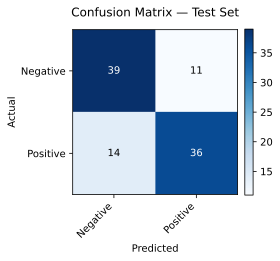

In [11]:
plot_confusion_matrix(
    model=model,
    loader=test_loader,
    num_classes=2,
    class_names=['Negative', 'Positive'],
    title='Confusion Matrix — Test Set',
)

---
## Scaling Up — 25 K Amazon Reviews

We now repeat the **exact same pipeline** on the larger `amazon_cells_labelled.txt` dataset (same tab-separated format, same binary labels).  The vectoriser and model are retrained **from scratch** on this corpus so the vocabulary properly reflects the larger training distribution.

### Load Pre-split Data

In [12]:
train_df = pd.read_csv(SPLITS_DIR / '25k_train.csv')
val_df   = pd.read_csv(SPLITS_DIR / '25k_val.csv')
test_df  = pd.read_csv(SPLITS_DIR / '25k_test.csv')

X_train = train_df['Sentence'].values.astype('U')
X_val   = val_df['Sentence'].values.astype('U')
X_test  = test_df['Sentence'].values.astype('U')
y_train = train_df['Class'].values.astype('int32')
y_val   = val_df['Class'].values.astype('int32')
y_test  = test_df['Class'].values.astype('int32')

print(f'Train: {len(X_train):,}  |  Val: {len(X_val):,}  |  Test: {len(X_test):,}')

Train: 20,250  |  Val: 2,250  |  Test: 2,500


### TF-IDF Vectorisation

In [13]:
vectorizer = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    max_features=50_000,
    max_df=0.5,
    use_idf=True,
    norm='l2',
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf   = vectorizer.transform(X_val)
X_test_tfidf  = vectorizer.transform(X_test)

print(f'TF-IDF features: {X_train_tfidf.shape[1]:,}')

TF-IDF features: 50,000


In [15]:
N_COMPONENTS = 500

svd = TruncatedSVD(n_components=N_COMPONENTS, n_iter=2, random_state=SEED)

X_train_svd = svd.fit_transform(X_train_tfidf)
X_val_svd   = svd.transform(X_val_tfidf)
X_test_svd  = svd.transform(X_test_tfidf)

print(f'SVD: {X_train_tfidf.shape[1]:,} → {N_COMPONENTS} components  '
      f'({svd.explained_variance_ratio_.sum():.1%} variance explained)')

X_train_t = torch.from_numpy(X_train_svd).float()
X_val_t   = torch.from_numpy(X_val_svd).float()
X_test_t  = torch.from_numpy(X_test_svd).float()

y_train_t = torch.from_numpy(y_train).long()
y_val_t   = torch.from_numpy(y_val).long()
y_test_t  = torch.from_numpy(y_test).long()

INPUT_DIM = N_COMPONENTS

SVD: 50,000 → 500 components  (25.6% variance explained)


### DataLoaders

In [16]:
BATCH_SIZE = 256

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
)
val_loader = DataLoader(
    TensorDataset(X_val_t, y_val_t),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
)
test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
)

### Model, Training & Evaluation

In [17]:
HIDDEN_DIMS    = [256, 64]
ACTIVATION     = nn.ReLU()
DROPOUT        = 0.5
NUM_EPOCHS     = 50
LEARNING_RATE  = 1e-4
WEIGHT_DECAY   = 1e-3

model = SentimentANN(
    input_dim=INPUT_DIM, hidden_dims=HIDDEN_DIMS,
    num_classes=2, dropout=DROPOUT, activation=ACTIVATION,
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

wandb_kwargs = dict(
    entity='d7047e-group12',
    project='Lab1',
    name='TFIDF ANN 25K',
    tags=['Task 1.1', 'ANN', 'TFIDF', 'SVD', '25K'],
    config={
        'dataset': 'Amazon 25K',
        'activation': ACTIVATION,
        'optimizer': optimizer,
        'hidden_dims': HIDDEN_DIMS,
        'num_classes': 2,
        'weight_decay': WEIGHT_DECAY,
        'lr': LEARNING_RATE,
        'epochs': NUM_EPOCHS,
        'batch_size': BATCH_SIZE,
    },
)

history = fit(
    model=model, optimizer=optimizer, criterion=criterion,
    train_loader=train_loader, val_loader=val_loader,
    num_epochs=NUM_EPOCHS, wandb_kwargs=wandb_kwargs, log=LOG_WANDB,
)

      Epoch | Train Loss |  Train Acc |   Val Loss |    Val Acc
Epoch  1/50 |     0.6888 |     56.91% |     0.6297 |     67.47%
Epoch  2/50 |     0.6239 |     64.74% |     0.5391 |     77.33%
Epoch  3/50 |     0.5579 |     71.46% |     0.4757 |     81.51%
Epoch  4/50 |     0.4991 |     75.96% |     0.4216 |     83.11%
Epoch  5/50 |     0.4538 |     79.23% |     0.3926 |     83.96%
Epoch 10/50 |     0.3642 |     84.16% |     0.3433 |     85.11%
Epoch 15/50 |     0.3340 |     85.46% |     0.3366 |     85.47%
Epoch 20/50 |     0.3122 |     86.72% |     0.3379 |     85.60%
Epoch 25/50 |     0.2932 |     87.47% |     0.3352 |     85.87%
Epoch 30/50 |     0.2743 |     88.35% |     0.3437 |     85.78%
Epoch 35/50 |     0.2524 |     89.69% |     0.3408 |     86.13%
Epoch 40/50 |     0.2379 |     89.96% |     0.3481 |     86.00%
Epoch 45/50 |     0.2227 |     90.75% |     0.3572 |     85.82%
Epoch 50/50 |     0.1994 |     91.64% |     0.3597 |     86.04%

Restored best weights (val loss 0.3343)

### Test-Set Evaluation & Confusion Matrix

In [18]:
evaluate(model, test_loader, criterion, label='ANN TF-IDF — 25K Samples')

[ANN TF-IDF — 25K Samples] Test loss: 0.3416 | Test acc: 84.60%


(0.3416076195716858, 84.6)

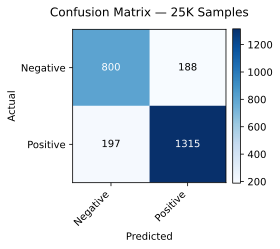

In [19]:
plot_confusion_matrix(
    model=model,
    loader=test_loader,
    num_classes=2,
    class_names=['Negative', 'Positive'],
    title='Confusion Matrix — 25K Samples',
)

---
## Video Games Reviews — 5-Class Rating

Same pipeline applied to the Video Games dataset. The key differences from the
binary sentiment tasks are:
- **5 output classes** (star ratings 1–5), remapped to 0–4 for `CrossEntropyLoss`.
- **Larger corpus** (~2.56 M reviews) so we use a bigger vocabulary and batch size.
- **Imbalanced classes** — 5-star reviews are ~58 % of the data.

### Load Pre-split Data

In [ ]:
train_df = pd.read_csv(SPLITS_DIR / 'vg_train.csv')
val_df   = pd.read_csv(SPLITS_DIR / 'vg_val.csv')
test_df  = pd.read_csv(SPLITS_DIR / 'vg_test.csv')

X_train = train_df['Sentence'].values.astype('U')
X_val   = val_df['Sentence'].values.astype('U')
X_test  = test_df['Sentence'].values.astype('U')

# Remap star ratings 1–5 → 0–4 (CrossEntropyLoss requires 0-indexed targets)
y_train = (np.asarray(train_df['Class'], dtype='int32') - 1)
y_val   = (np.asarray(val_df['Class'],   dtype='int32') - 1)
y_test  = (np.asarray(test_df['Class'],  dtype='int32') - 1)

print(f'Train: {len(X_train):,}  |  Val: {len(X_val):,}  |  Test: {len(X_test):,}')

### TF-IDF Vectorization

In [ ]:
vectorizer = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    max_features=100_000,
    max_df=0.5,
    use_idf=True,
    norm='l2',
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf   = vectorizer.transform(X_val)
X_test_tfidf  = vectorizer.transform(X_test)

print(f'TF-IDF features: {X_train_tfidf.shape[1]:,}')

In [ ]:
N_COMPONENTS = 300

svd = TruncatedSVD(n_components=N_COMPONENTS, n_iter=2, random_state=SEED)

X_train_svd = svd.fit_transform(X_train_tfidf)
X_val_svd   = svd.transform(X_val_tfidf)
X_test_svd  = svd.transform(X_test_tfidf)

print(f'SVD: {X_train_tfidf.shape[1]:,} → {N_COMPONENTS} components  '
      f'({svd.explained_variance_ratio_.sum():.1%} variance explained)')

X_train_t = torch.from_numpy(X_train_svd).float()
X_val_t   = torch.from_numpy(X_val_svd).float()
X_test_t  = torch.from_numpy(X_test_svd).float()

y_train_t = torch.from_numpy(y_train).long()
y_val_t   = torch.from_numpy(y_val).long()
y_test_t  = torch.from_numpy(y_test).long()

INPUT_DIM = N_COMPONENTS

### DataLoaders

In [ ]:
BATCH_SIZE = 256

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
)
val_loader = DataLoader(
    TensorDataset(X_val_t, y_val_t),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
)
test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
)

### Model, Training & Evaluation

In [ ]:
HIDDEN_DIMS   = [256, 64]
ACTIVATION    = nn.ReLU()
DROPOUT       = 0.5
NUM_EPOCHS    = 50
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 1e-3

model = SentimentANN(
    input_dim=INPUT_DIM, hidden_dims=HIDDEN_DIMS,
    num_classes=5, dropout=DROPOUT, activation=ACTIVATION,
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

wandb_kwargs = dict(
    entity='d7047e-group12',
    project='Lab1',
    name='TFIDF ANN VG',
    tags=['Task 1.1', 'ANN', 'TFIDF', 'SVD', 'VG'],
    config={
        'dataset': 'Video Games',
        'activation': ACTIVATION,
        'optimizer': optimizer,
        'hidden_dims': HIDDEN_DIMS,
        'num_classes': 5,
        'weight_decay': WEIGHT_DECAY,
        'lr': LEARNING_RATE,
        'epochs': NUM_EPOCHS,
        'batch_size': BATCH_SIZE,
    },
)

history = fit(
    model=model, optimizer=optimizer, criterion=criterion,
    train_loader=train_loader, val_loader=val_loader,
    num_epochs=NUM_EPOCHS, wandb_kwargs=wandb_kwargs, log=LOG_WANDB,
)

### Test-Set Evaluation & Confusion Matrix

In [ ]:
evaluate(model, test_loader, criterion, label='ANN TF-IDF/SVD — Video Games')

In [ ]:
plot_confusion_matrix(
    model=model,
    loader=test_loader,
    num_classes=5,
    class_names=['1-star', '2-star', '3-star', '4-star', '5-star'],
    title='Confusion Matrix — Video Games',
)